# Инструменты для работы с языком

## Задача: классификация твитов по тональности

У нас есть датасет из твитов, про каждый указано, как он эмоционально окрашен: положительно или отрицательно. Задача: предсказывать эмоциональную окраску.

Скачиваем куски датасета положительные отрицательные

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [5]:
# считываем данные и заполняем общий датасет
# считываем данные и заполняем общий датасет
positive = pd.read_csv('csv/positive.csv', sep=';', usecols=[3], names=['text'])
positive['label'] = ['positive'] * len(positive)
negative = pd.read_csv('csv/negative.csv', sep=';', usecols=[3], names=['text'])
negative['label'] = ['negative'] * len(negative)
df = pd.concat([positive, negative], ignore_index=True)

In [6]:
df.tail()

,text,label
226829,Но не каждый хочет что то исправлять:( http://...,negative
226830,скучаю так :-( только @taaannyaaa вправляет мо...,negative
226831,"Вот и в школу, в говно это идти уже надо(",negative
226832,"RT @_Them__: @LisaBeroud Тауриэль, не грусти :...",negative
226833,Такси везет меня на работу. Раздумываю приплат...,negative


In [11]:
x_train, x_test, y_train, y_test = train_test_split(df.text, df.label)

## Baseline: классификация необработанных n-грамм

### Векторизаторы

In [12]:
from sklearn.linear_model import LogisticRegression # можно заменить на любимый классификатор
from sklearn.feature_extraction.text import CountVectorizer

Что такое n-граммы:

In [13]:
from nltk import ngrams

In [17]:
sent = 'Если б мне платили каждый раз'.split()
list(ngrams(sent, 1)) # униграммы

[('Если',), ('б',), ('мне',), ('платили',), ('каждый',), ('раз',)]

In [18]:
list(ngrams(sent, 2)) # биграммы

[('Если', 'б'),
 ('б', 'мне'),
 ('мне', 'платили'),
 ('платили', 'каждый'),
 ('каждый', 'раз')]

In [19]:
list(ngrams(sent, 3)) # триграммы

[('Если', 'б', 'мне'),
 ('б', 'мне', 'платили'),
 ('мне', 'платили', 'каждый'),
 ('платили', 'каждый', 'раз')]

In [20]:
list(ngrams(sent, 5)) # ... пентаграммы?

[('Если', 'б', 'мне', 'платили', 'каждый'),
 ('б', 'мне', 'платили', 'каждый', 'раз')]

Самый простой способ извлечь фичи из текстовых данных -- векторизаторы: `CountVectorizer` и `TfidfVectorizer`

Объект `CountVectorizer` делает простую вещь:
* строит для каждого документа (каждой пришедшей ему строки) вектор размерности `n`, где `n` -- количество слов или n-грам во всём корпусе
* заполняет каждый i-тый элемент количеством вхождений слова в данный документ

In [21]:
vec = CountVectorizer(ngram_range=(1, 1))
bow = vec.fit_transform(x_train) # bow -- bag of words (мешок слов)

ngram_range отвечает за то, какие n-граммы мы используем в качестве фичей:<br/>
ngram_range=(1, 1) -- униграммы<br/>
ngram_range=(3, 3) -- триграммы<br/>
ngram_range=(1, 3) -- униграммы, биграммы и триграммы.

В vec.vocabulary_ лежит словарь: мэппинг слов к их индексам:

In [22]:
list(vec.vocabulary_.items())[:10]

[('всем', 115681),
 ('хорошего', 234489),
 ('настроения', 164890),
 ('http', 38089),
 ('co', 21464),
 ('1xulw7lzje', 1682),
 ('rt', 74706),
 ('vitrovarr', 89703),
 ('його', 142364),
 ('лице', 153607)]

In [23]:
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in t

In [24]:
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.77      0.77      0.77     28068
    positive       0.77      0.77      0.77     28641

    accuracy                           0.77     56709
   macro avg       0.77      0.77      0.77     56709
weighted avg       0.77      0.77      0.77     56709



Попробуем сделать то же самое для триграмм:

In [25]:
vec = CountVectorizer(ngram_range=(3, 3))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.47      0.72      0.57     18239
    positive       0.82      0.61      0.70     38470

    accuracy                           0.65     56709
   macro avg       0.64      0.66      0.63     56709
weighted avg       0.71      0.65      0.66     56709



(как вы думаете, почему в результатах теперь такой разброс по сравнению с униграммами?)

## TF-IDF векторизация

`TfidfVectorizer` делает то же, что и `CountVectorizer`, но в качестве значений – tf-idf каждого слова.

Как считается tf-idf:

TF (term frequency) – относительная частотность слова в документе:
$$ TF(t,d) = \frac{n_t}{\sum_k n_k} $$

`t` -- слово (term), `d` -- документ, $n_t$ -- количество вхождений слова, $n_k$ -- количество вхождений остальных слов

IDF (inverse document frequency) – обратная частота документов, в которых есть это слово:
$$ IDF(t, D) = \mbox{log} \frac{|D|}{|{d : t \in d}|} $$

`t` -- слово (term), `D` -- коллекция документов

Перемножаем их:
$$TFIDF_(t,d,D) = TF(t,d) \times IDF(i, D)$$

Сакральный смысл – если слово часто встречается в одном документе, но в целом по корпусу встречается в небольшом
количестве документов, у него высокий TF-IDF.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
vec = TfidfVectorizer(ngram_range=(1, 1))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.73      0.77      0.75     26632
    positive       0.79      0.75      0.77     30077

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709



В этот раз получилось хуже :( Вернёмся к `CountVectorizer`.

## PMI

Можно оценить взаимосвязь слов в корпусе и понять, какие биграммы наиболее часто встречаются в тексте. Для этого можно использовать метрику PMI (Pointwise Mutual Information) - поточечная взаимная информация. Метрика PMI для двух слов вычисляется по формуле:

$$pmi(x; y) = log \frac{p(x,y)}{p(x)p(y)} $$

Здесь p(y|x) - вероятность встретить слово $y$ после $x$, $p(y)$ - вероятность встретить слово $y$.

Оценим важность биграмм в нашем обучающем корпусе.

In [28]:
import nltk  # Импортируем библиотеку nltk
nltk.download('punkt')  # Загружаем необходимый ресурс для токенизации

import nltk  # Импортируем библиотеку nltk
from nltk import collocations  # Импортируем модуль collocations

nltk.download('genesis')

print(type(nltk.corpus.genesis.words('english-web.txt')))
bigram_measures = collocations.BigramAssocMeasures()
# bigram_finder.apply_freq_filter(5)
bigram_finder = collocations.BigramCollocationFinder.from_documents([nltk.word_tokenize(x) for x in x_train])
bigrams = bigram_finder.nbest(bigram_measures.pmi, 100)
print(bigrams)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\37727\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package genesis to
[nltk_data]     C:\Users\37727\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\genesis.zip.


<class 'nltk.corpus.reader.util.StreamBackedCorpusView'>
[('+СОННО', '+НЕ'), ('+живіт', 'болить.ну'), ('+погода', 'крутая='), (',4', 'запирайте'), (',как', 'додики'), ('-/////', 'прбрм-прбрм'), ('-10,11', 'болсо'), ('-163', '-КРАСНЫЙ'), ('-165', '-СИНИЙ'), ('-53', 'dBm'), ('-АХАХАХАХ', 'ЮБКУ'), ('-АХАХАХАХХАХАХАХАХАХХА', '-АХАХАХХАХАХАХАХАХ'), ('-Айгуль', 'Маратовна'), ('-Алина', '-Синие'), ('-Аха', 'спетросянил'), ('-Белоснежная', 'мантия'), ('-ВАХАХАХА', 'СТИПЕНДИЯ'), ('-ВСЕМ', 'СПОКОЙНЫХ'), ('-Вам', 'завернуть'), ('-Весело', 'кншн:3'), ('-Восьмигрудый', 'трипи'), ('-Время', 'эмокора'), ('-ГНИДОТА', '-Над'), ('-Д-Д-Д-Д-Д-Д-ДРОП', 'ЗЭ'), ('-ДЕТЕЙ', 'НАКРЫЛО'), ('-ДОВАЙТИ', 'АЛДСКУЛ'), ('-Домашка', '-кл.час'), ('-ЖРАТЬ', 'БАРАНКИ'), ('-Защитано', '-ес'), ('-КРАСНЫЙ', '-ЧЕРНЫЕ'), ('-Керем', 'севгили'), ('-Корнейчук', 'затроллила'), ('-Лера', 'Синим'), ('-МНОГО', 'СЛИВОК'), ('-Маладец', '-Лол'), ('-ОЗВУЧИВАТЕЛЬ', 'МУЛЬТИКОВ'), ('-Олесь', '-Пошёл'), ('-Песня', 'грусная='), ('-Плохое', 'пи

Можно рассмотреть другие метрики оценки важности биграмм, например, метрику правдоподобия (подробнее про вычисление метрики можно посмотреть [здесь (пункт 5.3.4)](http://www.corpus.unam.mx/cursoenah/ManningSchutze_1999_FoundationsofStatisticalNaturalLanguageProcessing.pdf):

In [29]:
bigrams = bigram_finder.nbest(bigram_measures.likelihood_ratio, 100)
print(bigrams)

[('(', '('), ('RT', '@'), (')', ')'), ('http', ':'), ('!', '!'), (':', 'D'), ('у', 'меня'), (':', '('), (',', 'а'), (',', 'что'), (',', 'но'), (')', 'http'), ('*', '*'), ('у', 'нас'), (':', ')'), ('(', ','), (':', '-'), ('не', 'могу'), (',', '('), (',', ')'), ('?', '?'), (')', ','), (',', ':'), (',', ','), ('(', ':'), (':', ','), ('&', 'lt'), ('@', ','), ('со', 'мной'), ('@', ':'), ('(', '@'), ('новый', 'год'), (':', ':'), (';', ')'), ('gt', ';'), (':', '*'), (')', ':'), ('не', 'знаю'), (',', '@'), ('@', '@'), ('а', 'я'), ('У', 'меня'), (',', 'когда'), ('сих', 'пор'), ('lt', ';'), ('потому', 'что'), ('&', 'gt'), ('у', 'тебя'), (';', '('), ('все', 'равно'), ('с', 'тобой'), (',', 'как'), ('в', 'школу'), ('(', 'http'), ('ничего', 'не'), (')', '@'), ('&', 'amp'), (',', 'я'), ('-', ')'), (':', 'DD'), ('я', 'не'), ('Доброе', 'утро'), ('Как', 'же'), ('не', '('), ('самом', 'деле'), ('--', '--'), ('не', ')'), ('до', 'сих'), ('как', 'же'), ('(', '!'), ('об', 'этом'), (',', '!'), ('никто', 'не'),

Как можно заметить, немаловажную роль в текстах занимает пунктуация.

## Стоп-слова и пунктуация

*Стоп-слова* -- это слова, которые часто встречаются практически в любом тексте и ничего интересного не говорят о конретном документе, то есть играют роль шума. Поэтому их принято убирать. По той же причине убирают и пунктуацию.

In [30]:
# у вас здесь, вероятно, выскочит ошибка и надо будет загрузить стоп слова (в тексте ошибки написано, как)
from nltk.corpus import stopwords
nltk.download('stopwords')
print(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\37727\AppData\Roaming\nltk_data...


['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

[nltk_data]   Unzipping corpora\stopwords.zip.


In [15]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [32]:
noise = stopwords.words('russian') + list(punctuation)

В векторизаторах за стоп-слова, логичным образом, отвечает аргумент `stop_words`.

In [33]:
vec = CountVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize, stop_words=noise)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``'] not in stop_words.
  warnings.warn(


              precision    recall  f1-score   support

    negative       0.80      0.77      0.79     29253
    positive       0.76      0.80      0.78     27456

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709



Получилось чууть лучше. Что ещё можно сделать?

In [34]:
!wget http://download.cdn.yandex.net/mystem/mystem-3.0-linux3.1-64bit.tar.gz
!tar -xvf mystem-3.0-linux3.1-64bit.tar.gz
!cp mystem /bin

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
tar: Error opening archive: Failed to open 'mystem-3.0-linux3.1-64bit.tar.gz'
"cp" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


## Лемматизация

Лемматизация – это сведение разных форм одного слова к начальной форме – *лемме*. Почему это хорошо?
* Во-первых, мы хотим рассматривать как отдельную фичу каждое *слово*, а не каждую его отдельную форму.
* Во-вторых, некоторые стоп-слова стоят только в начальной форме, и без лематизации выкидываем мы только её.

Для русского есть два хороших лемматизатора: mystem и pymorphy:

### [Mystem](https://tech.yandex.ru/mystem/)
Как с ним работать:
* можно скачать mystem и запускать [из терминала с разными параметрами](https://tech.yandex.ru/mystem/doc/)
* [pymystem3](https://pythonhosted.org/pymystem3/pymystem3.html) - обертка для питона, работает медленнее, но это удобно

In [35]:
%pip install pymystem3
from pymystem3 import Mystem
mystem_analyzer = Mystem()

"pip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


ModuleNotFoundError: No module named 'pymystem3'

Мы инициализировали Mystem c дефолтными параметрами. А вообще параметры есть такие:
* mystem_bin - путь к `mystem`, если их несколько
* grammar_info - нужна ли грамматическая информация или только леммы (по дефолту нужна)
* disambiguation - нужно ли снятие омонимии - дизамбигуация (по дефолту нужна)
* entire_input - нужно ли сохранять в выводе все (пробелы всякие, например), или можно выкинуть (по дефолту оставляется все)

Методы Mystem принимают строку, токенизатор вшит внутри. Можно, конечно, и пословно анализировать, но тогда он не сможет учитывать контекст.

Можно просто лемматизировать текст:

In [ ]:
print(mystem_analyzer.lemmatize(example))

NameError: name 'example' is not defined

А можно получить грамматическую информацию:

In [ ]:
mystem_analyzer.analyze(example)

NameError: name 'example' is not defined

Давайте терепь используем лемматизатор майстема в качестве токенизатора.

In [ ]:
import re
def my_preproc(text):
    text = re.sub('[{}]'.format(punctuation), '', text)
    text = mystem_analyzer.lemmatize(text)
    return [word for word in text if word not in stopwords.words('russian') + [' ', '\n']]

In [ ]:
vec = CountVectorizer(ngram_range=(1, 1), tokenizer=my_preproc)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

### [Pymorphy](http://pymorphy2.readthedocs.io/en/latest/)
Это модуль на питоне, довольно быстрый и с кучей функций.

In [ ]:
!pip install pymorphy2

In [ ]:
from pymorphy2 import MorphAnalyzer
pymorphy2_analyzer = MorphAnalyzer()

pymorphy2 работает с отдельными словами. Если дать ему на вход предложение - он его просто не лемматизирует, т.к. не понимает

In [ ]:
ana = pymorphy2_analyzer.parse(sent[3])
ana

In [ ]:
ana[0].normal_form

### [Natasha](https://github.com/natasha/)

В библиотеке natasha реализовано множество полезных библиотек для русского языка: разбиение на токены и предложения, русскоязычные word embeddings, морфологический, синтаксический анализ, лемматизация, извлечение именованных сущностей и т.д. Модуль библиотеки Razdel, основанный на правилах, предназначен для разбиения текста на токены и предложения.

In [ ]:
!pip install razdel

In [ ]:
from razdel import tokenize

tokens = list(tokenize('Кружка-термос на 0.5л (50/64 см³, 516;...)'))
tokens

[Substring(0, 13, 'Кружка-термос'),
 Substring(14, 16, 'на'),
 Substring(17, 20, '0.5'),
 Substring(20, 21, 'л'),
 Substring(22, 23, '('),
 Substring(23, 28, '50/64'),
 Substring(29, 32, 'см³'),
 Substring(32, 33, ','),
 Substring(34, 37, '516'),
 Substring(37, 38, ';'),
 Substring(38, 41, '...'),
 Substring(41, 42, ')')]

In [ ]:
[_.text for _ in tokens]

['Кружка-термос',
 'на',
 '0.5',
 'л',
 '(',
 '50/64',
 'см³',
 ',',
 '516',
 ';',
 '...',
 ')']

In [ ]:
!pip install natasha

     |████████████████████████████████| 34.4 MB 30 kB/s 
     |████████████████████████████████| 41 kB 102 kB/s 
     |████████████████████████████████| 49 kB 4.0 MB/s 
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26119 sha256=c21bb14c19f5774a60e5bb5d903ac3f80d37a2760af69683789029fcfa71fc54
  Stored in directory: /root/.cache/pip/wheels/16/85/bd/1001cbb46dcfb71c2001cd7401c6fb250392f22a81ce3722f7
Successfully built intervaltree
  Attempting uninstall: intervaltree
    Found existing installation: intervaltree 2.1.0
    Uninstalling intervaltree-2.1.0:
      Successfully uninstalled intervaltree-2.1.0


С помощью библиотеки natasha можно также лемматизировать тексты.

In [ ]:
from natasha import Doc, MorphVocab, Segmenter, NewsEmbedding, NewsMorphTagger

segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

def natasha_lemmatize(text):
  doc = Doc(text)
  doc.segment(segmenter)
  doc.tag_morph(morph_tagger)
  for token in doc.tokens:
    token.lemmatize(morph_vocab)
  return {_.text: _.lemma for _ in doc.tokens}

In [ ]:
text = 'Посол Израиля на Украине Йоэль Лион признался, что пришел в шок, узнав о решении властей Львовской области объявить 2019 год годом лидера запрещенной в России Организации украинских националистов (ОУН) Степана Бандеры. Свое заявление он разместил в Twitter. «Я не могу понять, как прославление тех, кто непосредственно принимал участие в ужасных антисемитских преступлениях, помогает бороться с антисемитизмом и ксенофобией. Украина не должна забывать о преступлениях, совершенных против украинских евреев, и никоим образом не отмечать их через почитание их исполнителей», — написал дипломат. 11 декабря Львовский областной совет принял решение провозгласить 2019 год в регионе годом Степана Бандеры в связи с празднованием 110-летия со дня рождения лидера ОУН (Бандера родился 1 января 1909 года). В июле аналогичное решение принял Житомирский областной совет. В начале месяца с предложением к президенту страны Петру Порошенко вернуть Бандере звание Героя Украины обратились депутаты Верховной Рады. Парламентарии уверены, что признание Бандеры национальным героем поможет в борьбе с подрывной деятельностью против Украины в информационном поле, а также остановит «распространение мифов, созданных российской пропагандой». Степан Бандера (1909-1959) был одним из лидеров Организации украинских националистов, выступающей за создание независимого государства на территориях с украиноязычным населением. В 2010 году в период президентства Виктора Ющенко Бандера был посмертно признан Героем Украины, однако впоследствии это решение было отменено судом. '

natasha_lemmatize(text)

{'(': '(',
 ')': ')',
 ',': ',',
 '.': '.',
 '1': '1',
 '11': '11',
 '110-летия': '110-летие',
 '1909': '1909',
 '1909-1959': '1909-1959',
 '2010': '2010',
 '2019': '2019',
 'Twitter': 'twitter',
 '«': '«',
 '»': '»',
 'Бандера': 'бандера',
 'Бандере': 'бандера',
 'Бандеры': 'бандера',
 'В': 'в',
 'Верховной': 'верховный',
 'Виктора': 'виктор',
 'Героем': 'герой',
 'Героя': 'герой',
 'Житомирский': 'житомирский',
 'Израиля': 'израиль',
 'Йоэль': 'йоэль',
 'Лион': 'лион',
 'Львовский': 'львовский',
 'Львовской': 'львовский',
 'ОУН': 'оун',
 'Организации': 'организация',
 'Парламентарии': 'парламентарий',
 'Петру': 'петр',
 'Порошенко': 'порошенко',
 'Посол': 'посол',
 'Рады': 'рада',
 'России': 'россия',
 'Свое': 'свой',
 'Степан': 'степан',
 'Степана': 'степан',
 'Украина': 'украина',
 'Украине': 'украина',
 'Украины': 'украина',
 'Ющенко': 'ющенко',
 'Я': 'я',
 'а': 'а',
 'аналогичное': 'аналогичный',
 'антисемитизмом': 'антисемитизм',
 'антисемитских': 'антисемитский',
 'бороться': '

### mystem vs. pymorphy vs. natasha

1) *Мы надеемся, что вы пользуетесь линуксом*, но mystem работает невероятно медленно под windows на больших текстах.

2) *Снятие омонимии*. Mystem умеет снимать омонимию по контексту (хотя не всегда преуспевает), pymorphy2 берет на вход одно слово и соответственно вообще не умеет дизамбигуировать по контексту, natasha тоже с этим тоже не справляется успешно:

In [ ]:
homonym1 = 'За время обучения я прослушал больше сорока курсов.'
homonym2 = 'Сорока своровала блестящее украшение со стола.'

In [ ]:
mystem_analyzer = Mystem() # инициализирую объект с дефолтными параметрами

print(mystem_analyzer.analyze(homonym1)[-5])
print(mystem_analyzer.analyze(homonym2)[0])

{'analysis': [{'lex': 'сорок', 'wt': 0.8710292578, 'gr': 'NUM=(пр|дат|род|твор)'}], 'text': 'сорока'}
{'analysis': [{'lex': 'сорока', 'wt': 0.1210970059, 'gr': 'S,жен,од=им,ед'}], 'text': 'Сорока'}


In [ ]:
print(natasha_lemmatize(homonym1))

{'За': 'за', 'время': 'время', 'обучения': 'обучение', 'я': 'я', 'прослушал': 'прослушать', 'больше': 'большой', 'сорока': 'сорок', 'курсов': 'курс', '.': '.'}


In [ ]:
print(natasha_lemmatize(homonym2))

{'Сорока': 'сорок', 'своровала': 'своровать', 'блестящее': 'блестящий', 'украшение': 'украшение', 'со': 'с', 'стола': 'стол', '.': '.'}


## Словарь, закон Ципфа и закон Хипса

Закон Ципфа -- эмпирическая закономерность: если все слова корпуса текста упорядочить по убыванию частоты их использования, то частота n-го слова в таком списке окажется приблизительно обратно пропорциональной его порядковому номеру n. Иными словами, частотность слов убывает очень быстро.

In [9]:
from collections import Counter

In [17]:
corpus = [token for tweet in df.text for token in word_tokenize(tweet) if token not in punctuation]
print(len(corpus))
corpus[:10]

2870795


['first_timee', 'хоть', 'я', 'и', 'школота', 'но', 'поверь', 'у', 'нас', 'то']

In [18]:
freq_dict = Counter(corpus)
freq_dict_sorted= sorted(freq_dict.items(), key=lambda x: -x[1])
list(freq_dict_sorted)[:10]

[('не', 69474),
 ('и', 55168),
 ('в', 52902),
 ('я', 52820),
 ('RT', 38070),
 ('на', 35759),
 ('http', 32998),
 ('что', 31546),
 ('с', 27217),
 ('а', 26860)]

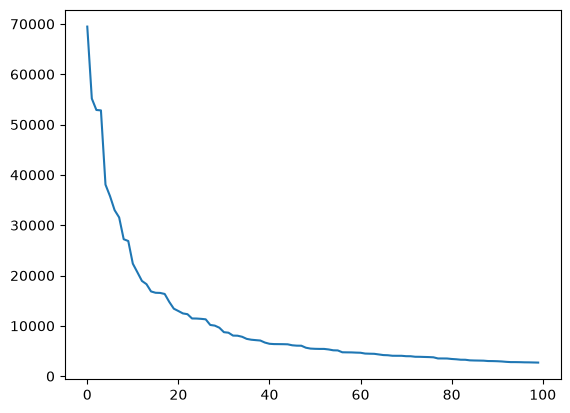

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
first_100_freqs = [freq for word, freq in freq_dict_sorted[:100]]
plt.plot(first_100_freqs)
plt.show()

Закон Хипса -- обратная сторона закона Ципфа. Он описывает, что чем больше корпус, тем меньше новых слов добавляется с добавлением новых текстов. В какой-то момент корпус насыщается.

## Задание 1.

**Задание**: обучите три классификатора:

1) на токенах с высокой частотой

2) на токенах со средней частотой

3) на токенах с низкой частотой

Сравните полученные результаты, оцените какие токены наиболее важные для классификации.

In [20]:
from nltk import word_tokenize

# Пороги частоты по закону Ципфа
HIGH_THR, LOW_THR = 100, 10

high_vocab = {w for w, c in freq_dict.items() if c > HIGH_THR}
mid_vocab = {w for w, c in freq_dict.items() if LOW_THR < c <= HIGH_THR}
low_vocab = {w for w, c in freq_dict.items() if c <= LOW_THR}

print(f'Высокая частота (>{HIGH_THR}): {len(high_vocab)} токенов')
print(f'Средняя частота ({LOW_THR + 1}..{HIGH_THR}): {len(mid_vocab)} токенов')
print(f'Низкая частота (<={LOW_THR}): {len(low_vocab)} токенов')


def train_on_vocab(vocab, title):
    vec_f = CountVectorizer(tokenizer=word_tokenize, vocabulary=list(vocab))
    bow_f = vec_f.fit_transform(x_train)
    clf_f = LogisticRegression(random_state=42, max_iter=500)
    clf_f.fit(bow_f, y_train)
    pred_f = clf_f.predict(vec_f.transform(x_test))
    print(f'\n=== {title} ===')
    print(classification_report(y_test, pred_f))
    return clf_f


train_on_vocab(high_vocab, 'Токены с высокой частотой')
train_on_vocab(mid_vocab, 'Токены со средней частотой')
train_on_vocab(low_vocab, 'Токены с низкой частотой')

Высокая частота (>100): 2393 токенов
Средняя частота (11..100): 16106 токенов
Низкая частота (<=10): 332431 токенов


C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:1379: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(



=== Токены с высокой частотой ===
              precision    recall  f1-score   support

    negative       0.71      0.69      0.70     27895
    positive       0.71      0.73      0.72     28814

    accuracy                           0.71     56709
   macro avg       0.71      0.71      0.71     56709
weighted avg       0.71      0.71      0.71     56709



C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:1379: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(



=== Токены со средней частотой ===
              precision    recall  f1-score   support

    negative       0.64      0.73      0.68     27895
    positive       0.70      0.61      0.65     28814

    accuracy                           0.67     56709
   macro avg       0.67      0.67      0.67     56709
weighted avg       0.67      0.67      0.67     56709



C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:1379: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(



=== Токены с низкой частотой ===
              precision    recall  f1-score   support

    negative       0.58      0.77      0.66     27895
    positive       0.68      0.47      0.55     28814

    accuracy                           0.61     56709
   macro avg       0.63      0.62      0.61     56709
weighted avg       0.63      0.61      0.61     56709



,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in t

**Вывод (задание 1).** Лучше всего работает словарь **высокочастотных** токенов (accuracy ≈ 0.74). Средняя частота заметно слабее (~0.65), низкая — ещё слабее (~0.62): редкие слова почти не пересекаются между train и test и плохо обобщаются. Для классификации важнее стабильные частые токены.

## О важности эксплоративного анализа

Но иногда пунктуация бывает и не шумом -- главное отталкиваться от задачи. Что будет если вообще не убирать пунктуацию?

In [22]:
vec = TfidfVectorizer(ngram_range=(1, 1), tokenizer=word_tokenize)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

C:\Users\37727\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     27842
    positive       1.00      1.00      1.00     28867

    accuracy                           1.00     56709
   macro avg       1.00      1.00      1.00     56709
weighted avg       1.00      1.00      1.00     56709



Шок! Стоило оставить пунктуацию -- и все метрики равны 1. Как это получилось? Среди неё были очень значимые токены (как вы думаете, какие?). Найдите фичи с самыми большими коэффициэнтами:

## Задание 2.

найти фичи с наибольшей значимостью, и вывести их

In [23]:
# Берём модель из ячейки выше (Tfidf + word_tokenize, пунктуация сохранена)
feature_names = vec.get_feature_names_out()
coefs = clf.coef_[0]  # classes_: ['negative', 'positive']

print('Порядок классов:', clf.classes_)
print('\nТоп-20 фичей по |coef|:')
for i in np.argsort(np.abs(coefs))[::-1][:20]:
    sign = 'positive' if coefs[i] > 0 else 'negative'
    print(f'{feature_names[i]!r:12}  coef={coefs[i]:+.3f}  -> {sign}')

Порядок классов: ['negative' 'positive']

Топ-20 фичей по |coef|:
'('           coef=-60.212  -> negative
')'           coef=+58.347  -> positive
'd'           coef=+27.987  -> positive
'|'           coef=-12.247  -> negative
'о_о'         coef=-12.099  -> negative
'dd'          coef=+10.507  -> positive
'o_o'         coef=-8.751  -> negative
'^_^'         coef=+8.329  -> positive
'-/'          coef=-8.199  -> negative
'*'           coef=+7.662  -> positive
'ddd'         coef=+7.220  -> positive
'-d'          coef=+7.169  -> positive
':'           coef=+7.150  -> positive
'rt'          coef=-4.942  -> negative
'to_over_kill'  coef=-4.810  -> negative
'cio_optimal'  coef=-4.537  -> negative
'do_or_die_xxx'  coef=-3.846  -> negative
'prisonero_o'  coef=-3.581  -> negative
'dddd'        coef=+3.323  -> positive
'снаступающимтвиттерский'  coef=-2.516  -> negative


In [24]:
print('Самые позитивные фичи:')
for i in np.argsort(coefs)[::-1][:10]:
    print(f'{feature_names[i]!r:12}  {coefs[i]:+.3f}')

print('\nСамые негативные фичи:')
for i in np.argsort(coefs)[:10]:
    print(f'{feature_names[i]!r:12}  {coefs[i]:+.3f}')

Самые позитивные фичи:
')'           +58.347
'd'           +27.987
'dd'          +10.507
'^_^'         +8.329
'*'           +7.662
'ddd'         +7.220
'-d'          +7.169
':'           +7.150
'dddd'        +3.323
'ddddd'       +1.936

Самые негативные фичи:
'('           -60.212
'|'           -12.247
'о_о'         -12.099
'o_o'         -8.751
'-/'          -8.199
'rt'          -4.942
'to_over_kill'  -4.810
'cio_optimal'  -4.537
'do_or_die_xxx'  -3.846
'prisonero_o'  -3.581


Посмотрим, как один из супер-значительных токенов справится с классификацией безо всякого машинного обучения:

In [25]:
cool_token = ')'
pred = ['positive' if cool_token in tweet else 'negative' for tweet in x_test]
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.85      1.00      0.92     27895
    positive       1.00      0.83      0.91     28814

    accuracy                           0.91     56709
   macro avg       0.92      0.91      0.91     56709
weighted avg       0.93      0.91      0.91     56709



**Вывод (задание 2).** Самые значимые фичи — скобки-смайлы: `)` усиливает класс *positive*, `(` — *negative*. Поэтому одного токена `)` уже достаточно для accuracy ≈ 0.91 без обучения модели. Пунктуация здесь не шум, а основной сигнал тональности.

## Символьные n-граммы

Теперь в качестве фичей используем, например, униграммы символов:

In [26]:
vec = CountVectorizer(analyzer='char', ngram_range=(1, 1))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99     27806
    positive       1.00      0.99      0.99     28903

    accuracy                           0.99     56709
   macro avg       0.99      0.99      0.99     56709
weighted avg       0.99      0.99      0.99     56709



В общем-то, теперь уже понятно, почему на этих данных здесь 1. Так или инчае, на символах классифицировать тоже можно: для некторых задач (например, для определения языка) фичи-символьные n-граммы решительно рулят.

Ещё одна замечательная особенность фичей-символов: токенизация и лемматизация не нужна, можно использовать такой подход для языков, у которых нет готвых анализаторов.

## Домашнее задание

все материалы для выполения дз в `sem2.ipynb`


### Задание 1.

**Задание**: обучите три классификатора:

1) на токенах с высокой частотой

2) на токенах со средней частотой

3) на токенах с низкой частотой


Сравните полученные результаты, оцените какие токены наиболее важные для классификации.


### Задание 2.

найти фичи с наибольшей значимостью, и вывести их


### Задание 3.

1) сравнить count/tf-idf/hashing векторайзеры/полносвязанную сетку (построить classification_report)

2) подобрать оптимальный размер для hashing векторайзера

3) убедиться что для сетки нет переобучения

### Задание 3 — решение

In [27]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Для честного сравнения не используем word_tokenize (иначе скобки-смайлы дают ~1.0)
y_train_bin = (y_train == 'positive').astype(int)
y_test_bin = (y_test == 'positive').astype(int)

def report(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    print(f'\n========== {name} ==========')
    print(classification_report(y_test, pred))
    return accuracy_score(y_test, pred)

results = {}

# 1) CountVectorizer + LogReg
vec_count = CountVectorizer(ngram_range=(1, 1))
Xtr = vec_count.fit_transform(x_train)
Xte = vec_count.transform(x_test)
results['Count'] = report('CountVectorizer + LogReg', LogisticRegression(random_state=42, max_iter=500), Xtr, Xte)

# 2) TfidfVectorizer + LogReg
vec_tfidf = TfidfVectorizer(ngram_range=(1, 1))
Xtr = vec_tfidf.fit_transform(x_train)
Xte = vec_tfidf.transform(x_test)
results['TF-IDF'] = report('TfidfVectorizer + LogReg', LogisticRegression(random_state=42, max_iter=500), Xtr, Xte)

# 3) HashingVectorizer + LogReg (базовый размер)
vec_hash = HashingVectorizer(ngram_range=(1, 1), n_features=2**14, alternate_sign=False)
Xtr = vec_hash.transform(x_train)
Xte = vec_hash.transform(x_test)
results['Hashing'] = report('HashingVectorizer(2**14) + LogReg', LogisticRegression(random_state=42, max_iter=500), Xtr, Xte)

# 4) Полносвязная сеть на TF-IDF (урезаем размерность через max_features)
vec_nn = TfidfVectorizer(ngram_range=(1, 1), max_features=5000)
Xtr_nn = vec_nn.fit_transform(x_train)
Xte_nn = vec_nn.transform(x_test)
mlp = MLPClassifier(hidden_layer_sizes=(64,), alpha=0.1, max_iter=30, random_state=42, early_stopping=True, validation_fraction=0.1)
results['MLP'] = report('TF-IDF(5k) + MLPClassifier', mlp, Xtr_nn, Xte_nn)

print('\nСводка accuracy:')
for k, v in results.items():
    print(f'  {k}: {v:.4f}')


========== CountVectorizer + LogReg ==========
              precision    recall  f1-score   support

    negative       0.76      0.77      0.76     27895
    positive       0.77      0.76      0.77     28814

    accuracy                           0.77     56709
   macro avg       0.77      0.77      0.77     56709
weighted avg       0.77      0.77      0.77     56709


========== TfidfVectorizer + LogReg ==========
              precision    recall  f1-score   support

    negative       0.77      0.73      0.75     27895
    positive       0.75      0.78      0.77     28814

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709


========== HashingVectorizer(2**14) + LogReg ==========
              precision    recall  f1-score   support

    negative       0.73      0.71      0.72     27895
    positive       0.72      0.74      0.73     28814

    accuracy                 

In [28]:
# Подбор n_features для HashingVectorizer
hash_sizes = [2**10, 2**12, 2**14, 2**16, 2**18]
hash_scores = {}

for n in hash_sizes:
    vec_h = HashingVectorizer(ngram_range=(1, 1), n_features=n, alternate_sign=False)
    Xtr_h = vec_h.transform(x_train)
    Xte_h = vec_h.transform(x_test)
    clf_h = LogisticRegression(random_state=42, max_iter=500)
    clf_h.fit(Xtr_h, y_train)
    acc = accuracy_score(y_test, clf_h.predict(Xte_h))
    hash_scores[n] = acc
    print(f'n_features={n:>7} (2**{n.bit_length()-1}) -> accuracy={acc:.4f}')

best_n = max(hash_scores, key=hash_scores.get)
print(f'\nОптимальный размер: n_features={best_n} (accuracy={hash_scores[best_n]:.4f})')

n_features=   1024 (2**10) -> accuracy=0.6637
n_features=   4096 (2**12) -> accuracy=0.6941
n_features=  16384 (2**14) -> accuracy=0.7237
n_features=  65536 (2**16) -> accuracy=0.7412
n_features= 262144 (2**18) -> accuracy=0.7480

Оптимальный размер: n_features=262144 (accuracy=0.7480)


In [29]:
# Проверка переобучения MLP: сравниваем accuracy на train и test
# alpha + early_stopping + небольшая сеть уменьшают переобучение
vec_nn = TfidfVectorizer(ngram_range=(1, 1), max_features=5000)
Xtr_nn = vec_nn.fit_transform(x_train)
Xte_nn = vec_nn.transform(x_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=0.1,
    max_iter=40,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
)
mlp.fit(Xtr_nn, y_train)

pred_train = mlp.predict(Xtr_nn)
pred_test = mlp.predict(Xte_nn)
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_test)

print('classification_report на TEST:')
print(classification_report(y_test, pred_test))
print(f'accuracy train: {acc_train:.4f}')
print(f'accuracy test:  {acc_test:.4f}')
print(f'разница train-test: {acc_train - acc_test:.4f}')
print(f'число эпох до остановки: {mlp.n_iter_}')

classification_report на TEST:
              precision    recall  f1-score   support

    negative       0.74      0.70      0.72     27895
    positive       0.72      0.76      0.74     28814

    accuracy                           0.73     56709
   macro avg       0.73      0.73      0.73     56709
weighted avg       0.73      0.73      0.73     56709

accuracy train: 0.7499
accuracy test:  0.7318
разница train-test: 0.0181
число эпох до остановки: 27


**Вывод (задание 3).**

1. **Сравнение векторайзеров** (accuracy): Count ~ 0.767, TF-IDF ~ 0.760, Hashing(2^14) ~ 0.725, MLP ~ 0.734. Count/TF-IDF близки и чуть лучше Hashing при 2^14; MLP на урезанном TF-IDF конкурентен линейным моделям.

2. **Размер HashingVectorizer.** Малый размер даёт коллизии и хуже качество: 2^10=0.665, 2^12=0.699, 2^14=0.725, 2^16=0.743, 2^18=0.751. Лучший из проверенных: **n_features=262144** (~0.751); после 2^16 прирост уже небольшой.

3. **Переобучение сетки.** С регуляризацией (alpha=0.1) и early_stopping: train ~ 0.750, test ~ 0.734, разница ~ 0.017 (эпох: 30). Зазор небольшой — сильного переобучения нет.